# Mackenzie dyke swarm ca. 1267 Ma paleomagnetic pole

## Geologic context

The Mackenzie dyke swarm is the giant ~1267 Ma radiating mafic dyke swarm of the
Canadian Shield, with associated sills (Tsezotene), the Coppermine River basalts,
and the Muskox intrusion, recording a major mantle-plume event. A U-Pb baddeleyite
age of 1267 ± 2 Ma (LeCheminant & Heaman, 1989) dates the swarm. The Mackenzie
diabase sampled here (Irving, Donaldson & Park, 1972; Great Slave Lake area)
carries a southwest-and-down primary magnetization, shown to be primary by a
positive baked-contact test.


## Paleomagnetic And Rock Magnetic Data

This notebook recreates the Irving et al. (1972) Mackenzie diabase pole at the
site level from the 10 sill/dike/lopolith sites (excluding the three baked-contact
sites), and reports the prior-compilation Mackenzie GRAND MEAN of Buchan et al.
(2000).

## Age Constraints

- nominal age: 1267 Ma, lomagage 1265 Ma, himagage 1269 Ma.
- LeCheminant and Heaman, 1989 dated 7 fractions of baddeleyite from four locations and got a concorida upper intercept age of 1267 ± 2 Ma. This age remains the most recent direct dating study for the Mackenzie dike swarm.

## References

- Paleomagnetic source: Buchan, K. L., Mertanen, S., Park, R. G., Pesonen, L. J., Elming, S.-Å., Abrahamsen, N., & Bylund, G. (2000). Comparing the drift of Laurentia and Baltica in the Proterozoic: The importance of key palaeomagnetic poles. Tectonophysics, 319(3), 167–198. https://doi.org/10.1016/s0040-1951(00)00032-9

- Geochronology / age-constraint note (compilation): LeCheminant, A. N., & Heaman, L. M. (1989). Mackenzie igneous events, Canada: Middle Proterozoic hotspot magmatism associated with ocean opening. Earth and Planetary Science Letters, 96(1–2), 38–48. https://doi.org/10.1016/0012-821x(89)90122-2
- Irving, E., Donaldson, J. A., & Park, J. K. (1972). Paleomagnetism of the western channel diabase and associated rocks, northwest territories. Canadian Journal of Earth Sciences, 9(8), 960–971. https://doi.org/10.1139/e72-080

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import matplotlib.pyplot as plt
import pandas as pd

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data

Loaded from `../data/1267_Mackenzie/`. The pole uses the 10 sill/dike/lopolith
sites; the baked-contact sites B63, B64, B29 are flagged `result_quality='b'`
(excluded from the mean, retained for the field test). Directions are in-situ.

In [2]:
sites_geo, _ = pt.load_magic_sites('../data/1267_Mackenzie/sites.txt')
sites_all, _ = pt.load_magic_sites('../data/1267_Mackenzie/sites.txt', drop_bad=False)
study_lat, study_lon = 62.5, 249.0
print(f'{len(sites_geo)} characteristic sites; baked-contact sites:',
      sites_all[sites_all['result_quality'] == 'b']['site'].tolist())
sites_geo[['site', 'lat', 'lon', 'dir_dec', 'dir_inc', 'dir_n_samples', 'vgp_lat', 'vgp_lon']]

10 characteristic sites; baked-contact sites: ['B63', 'B64', 'B29']


,site,lat,lon,dir_dec,dir_inc,dir_n_samples,vgp_lat,vgp_lon
0,S62,62.5,249.1,250,17,4,-1.3,180.8
1,S63,62.5,249.1,241,22,5,-2.5,190.0
2,S64,62.3,249.2,248,9,5,-6.0,180.9
3,L75,62.4,248.7,237,28,4,-0.9,194.5
4,S76,62.5,248.9,253,18,5,0.5,178.2
5,S78,62.2,248.4,247,15,5,-3.6,182.3
6,S86,62.3,248.4,259,28,5,8.2,175.0
7,D90,62.3,248.4,237,23,4,-3.7,193.1
8,D29,64.1,262.9,268,22,9,9.4,179.7
9,D175,66.9,240.9,253,27,3,6.7,172.0


Plon: 182.7  Plat: 0.7
Number of directions in mean (n): 10
Angular radius of 95% confidence (A_95): 5.6
Precision parameter (k) estimate: 76.3

Irving et al. (1972) Mackenzie diabase pole: 0.7 N / 182.7 E, A95 5.6, N=10
prior compilation Mackenzie dyke GRAND MEAN (Buchan et al., 2000): 4 N / 190 E, A95 5, N=5


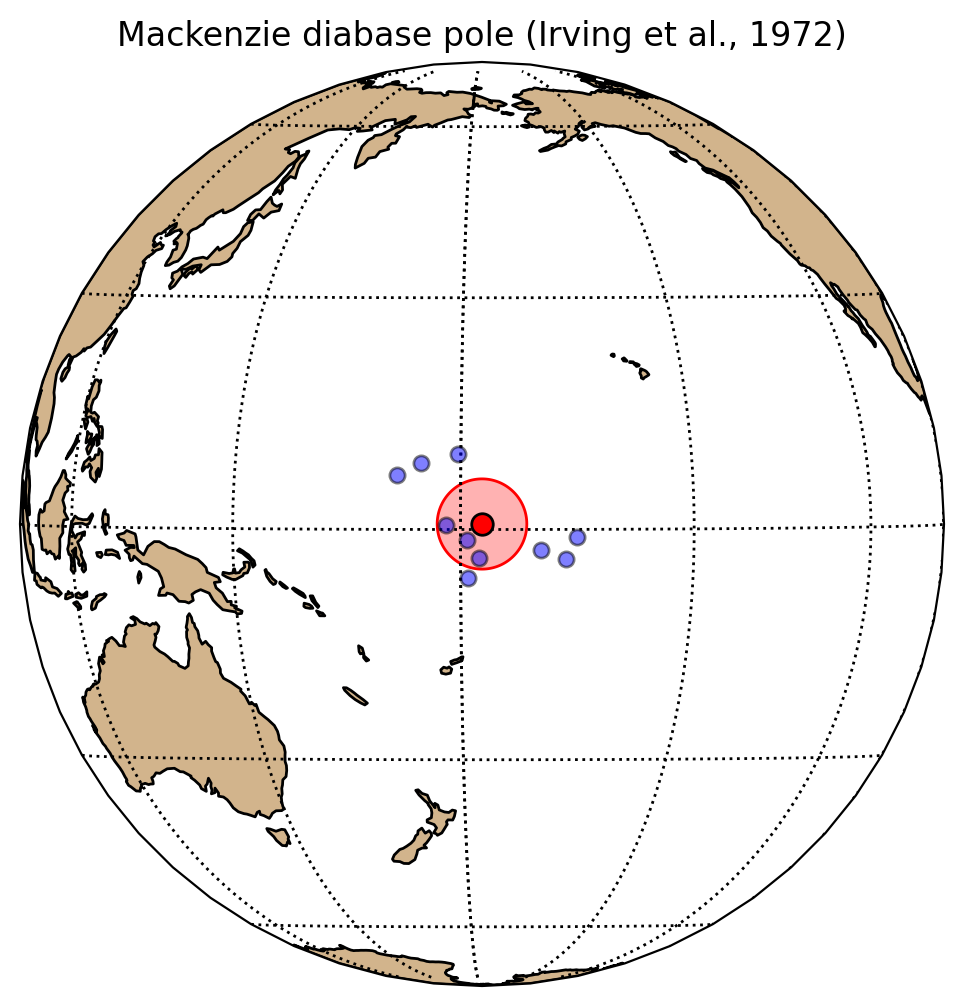

In [3]:
vgp_block, pole_mean = pt.compute_mean_pole(sites_geo, unify_polarity=True)
ipmag.print_pole_mean(pole_mean)
print('\nIrving et al. (1972) Mackenzie diabase pole: 0.7 N / 182.7 E, A95 5.6, N=10')
print('prior compilation Mackenzie dyke GRAND MEAN (Buchan et al., 2000): 4 N / 190 E, A95 5, N=5')
_ = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'], figsize=(6, 6))
plt.title('Mackenzie diabase pole (Irving et al., 1972)')
plt.show()

In [4]:
dir_block, dir_mean = pt.compute_mean_direction(sites_geo, unify_polarity=True)
ipmag.print_direction_mean(dir_mean)

Dec: 249.3  Inc: 21.1
Number of directions in mean (n): 10
Angular radius of 95% confidence (a_95): 6.5
Precision parameter (k) estimate: 55.5


## Field test: baked contact

The baked country-rock sites (B63, B64, B29), sampled at the contacts of the
diabase sills/dikes, carry the diabase direction — a positive baked-contact test
indicating the magnetization is primary.

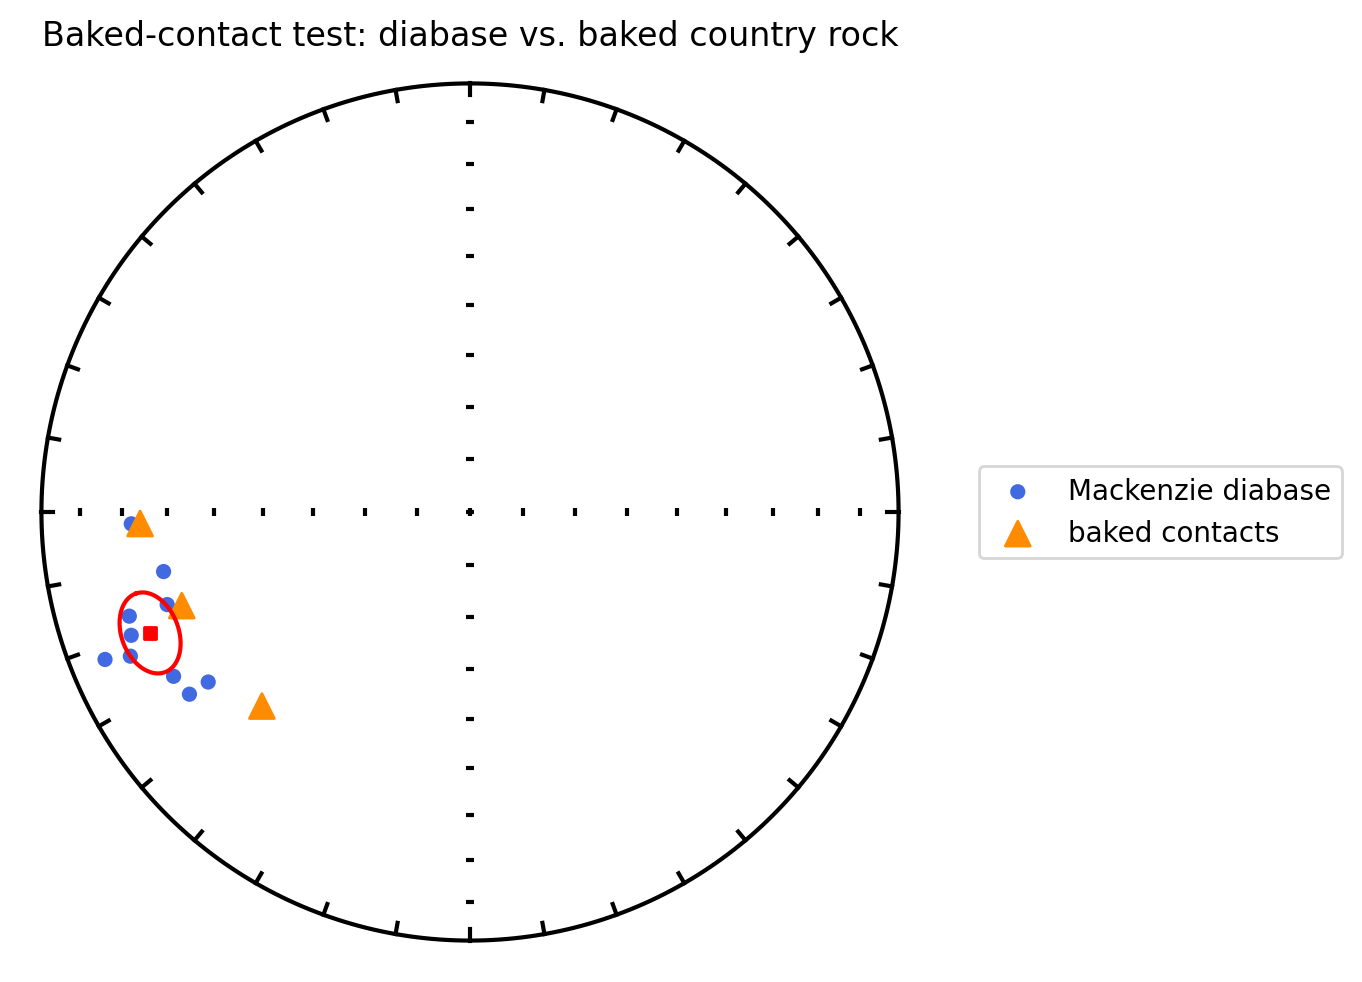

In [5]:
ipmag.plot_net()
ipmag.plot_di(sites_geo['dir_dec'].tolist(), sites_geo['dir_inc'].tolist(),
              color='royalblue', marker='o', label='Mackenzie diabase')
baked = sites_all[sites_all['result_quality'] == 'b']
ipmag.plot_di(baked['dir_dec'].tolist(), baked['dir_inc'].tolist(),
              color='darkorange', marker='^', markersize=80, label='baked contacts')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'], color='red', marker='s')
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.title('Baked-contact test: diabase vs. baked country rock')
plt.show()

## Paleosecular variation

A_95 of 5.6 passes Deenen et al. (2011) criteria of being between 4.8 and 19.2 for this number of sites


<Axes: title={'center': 'Deenen et al. (2011) test'}, xlabel='Number of sites (N)', ylabel='$A_{95}$ (°)'>

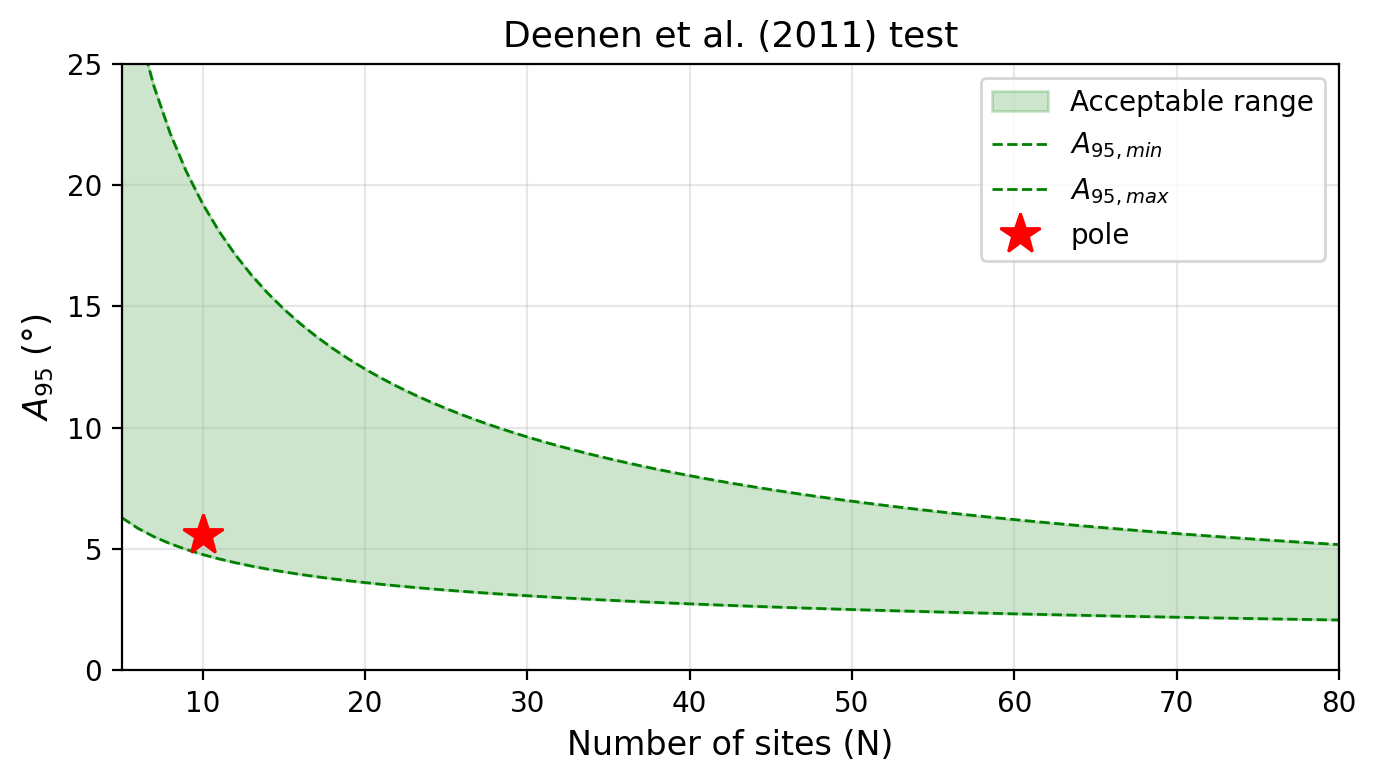

In [6]:
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)

## Paleosecular variation and VGP-shape diagnostics

The Fisher-quantile (fishqq) test assesses whether the site VGPs are drawn from a
Fisher distribution, and the shape-elongation/inclination (SVEI) test compares the
VGP-scatter elongation against the TK03.GAD paleosecular-variation model expectation
at the sampling paleolatitude.

{'Mode': 'Mode 1',
 'Dec': np.float64(182.65074634993746),
 'Inc': np.float64(0.6641180657333684),
 'N': 10,
 'Mu': np.float64(1.0072950656675086),
 'Mu_critical': 1.207,
 'Me': np.float64(0.772337850413828),
 'Me_critical': 1.094,
 'Test_result': 'Consistent with Fisher distribution'}

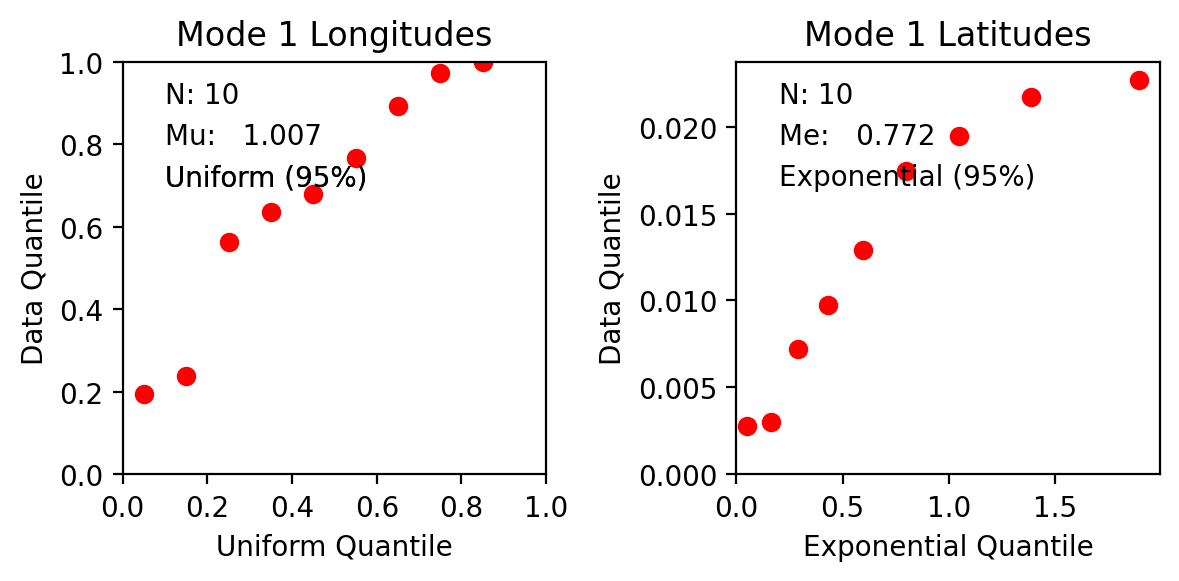

In [7]:
fishqq_result = pt.fishqq_vgps(sites_geo, unify_polarity=True)
fishqq_result

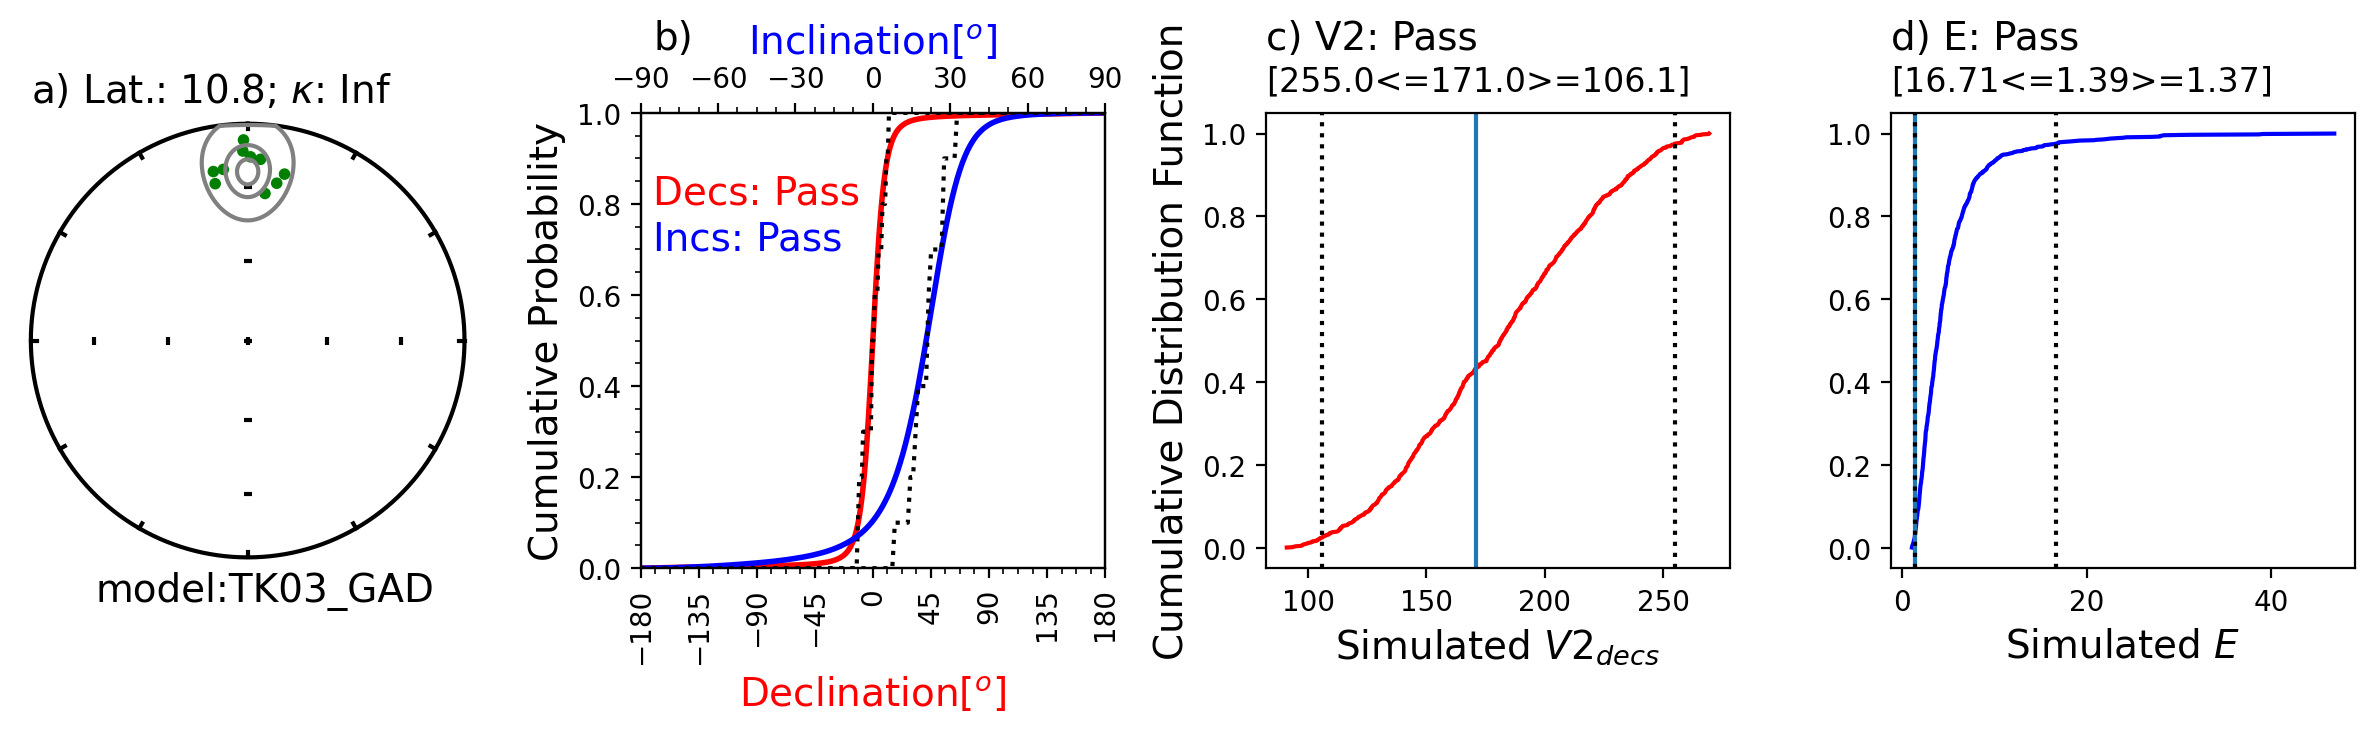

paleolatitude = 10.8 deg; elongation E = 1.39 (consistent with TK03.GAD)


In [8]:
_slat, _slon = float(sites_geo['lat'].mean()), float(sites_geo['lon'].mean())
try:
    svei_result = pt.svei_test_vgps(sites_geo, _slon, _slat, model='TK03_GAD', plot=True)
except TypeError:
    svei_result = pt.svei_test_vgps(sites_geo, _slon, _slat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped: E below the TK03.GAD model minimum)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

## The Mackenzie pole in the context of the Laurentia APWP

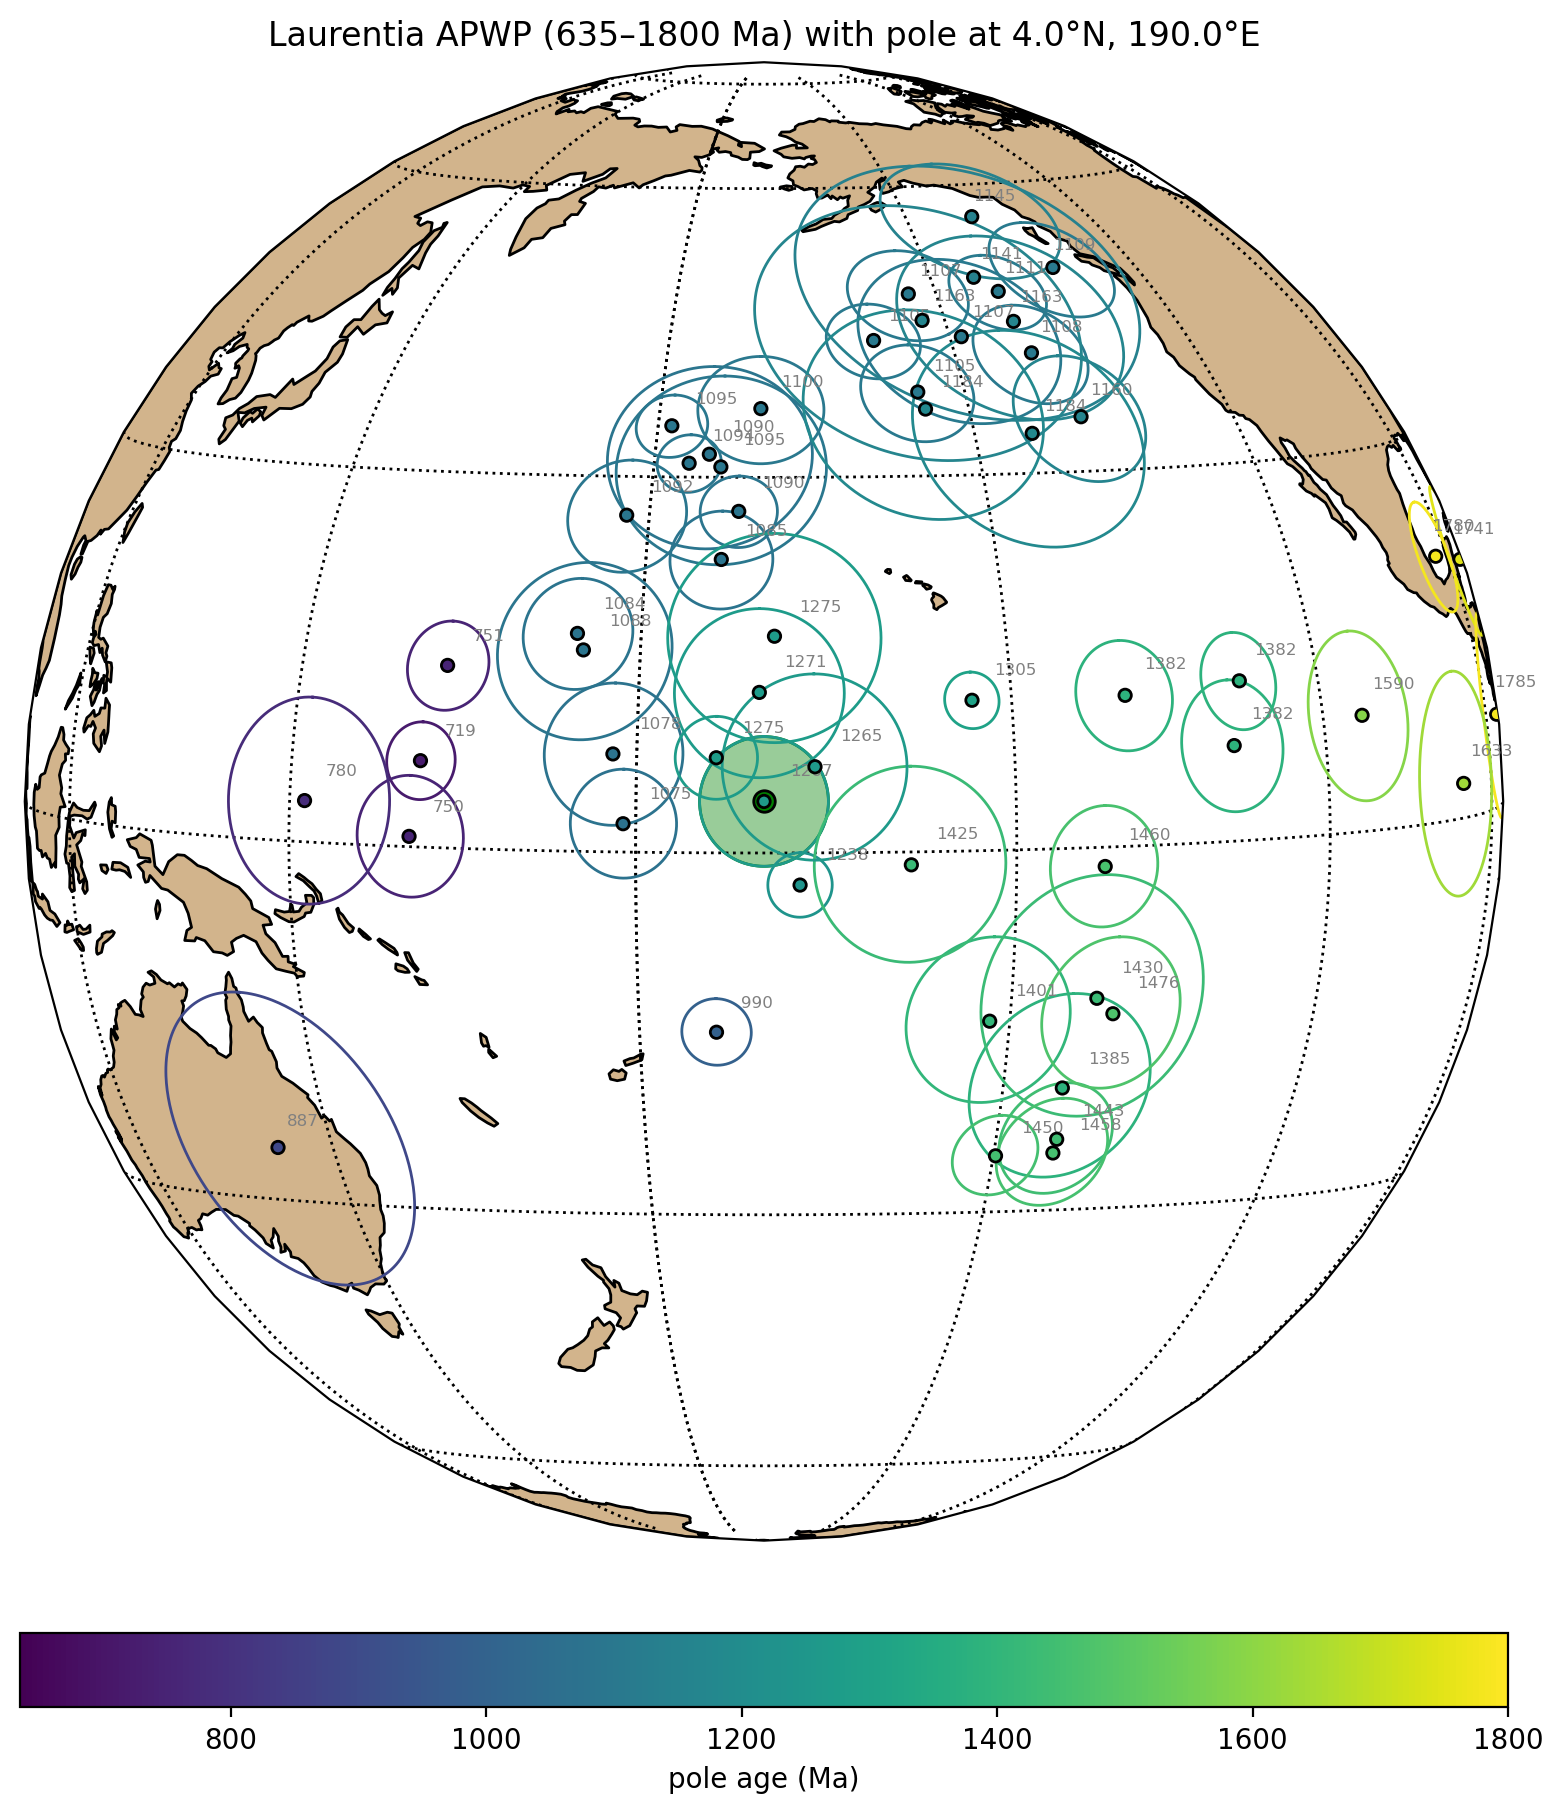

In [9]:
# adopted prior-compilation Mackenzie grand-mean pole (Buchan et al., 2000)
mackenzie_pole = {'inc': 4.0, 'dec': 190.0, 'alpha95': 5.0, 'n': 5}
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, mackenzie_pole['inc'], mackenzie_pole['dec'],
                          mackenzie_pole['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=mackenzie_pole['dec'],
                          central_latitude=mackenzie_pole['inc'])
plt.show()

## R7: comparison with younger Laurentia poles

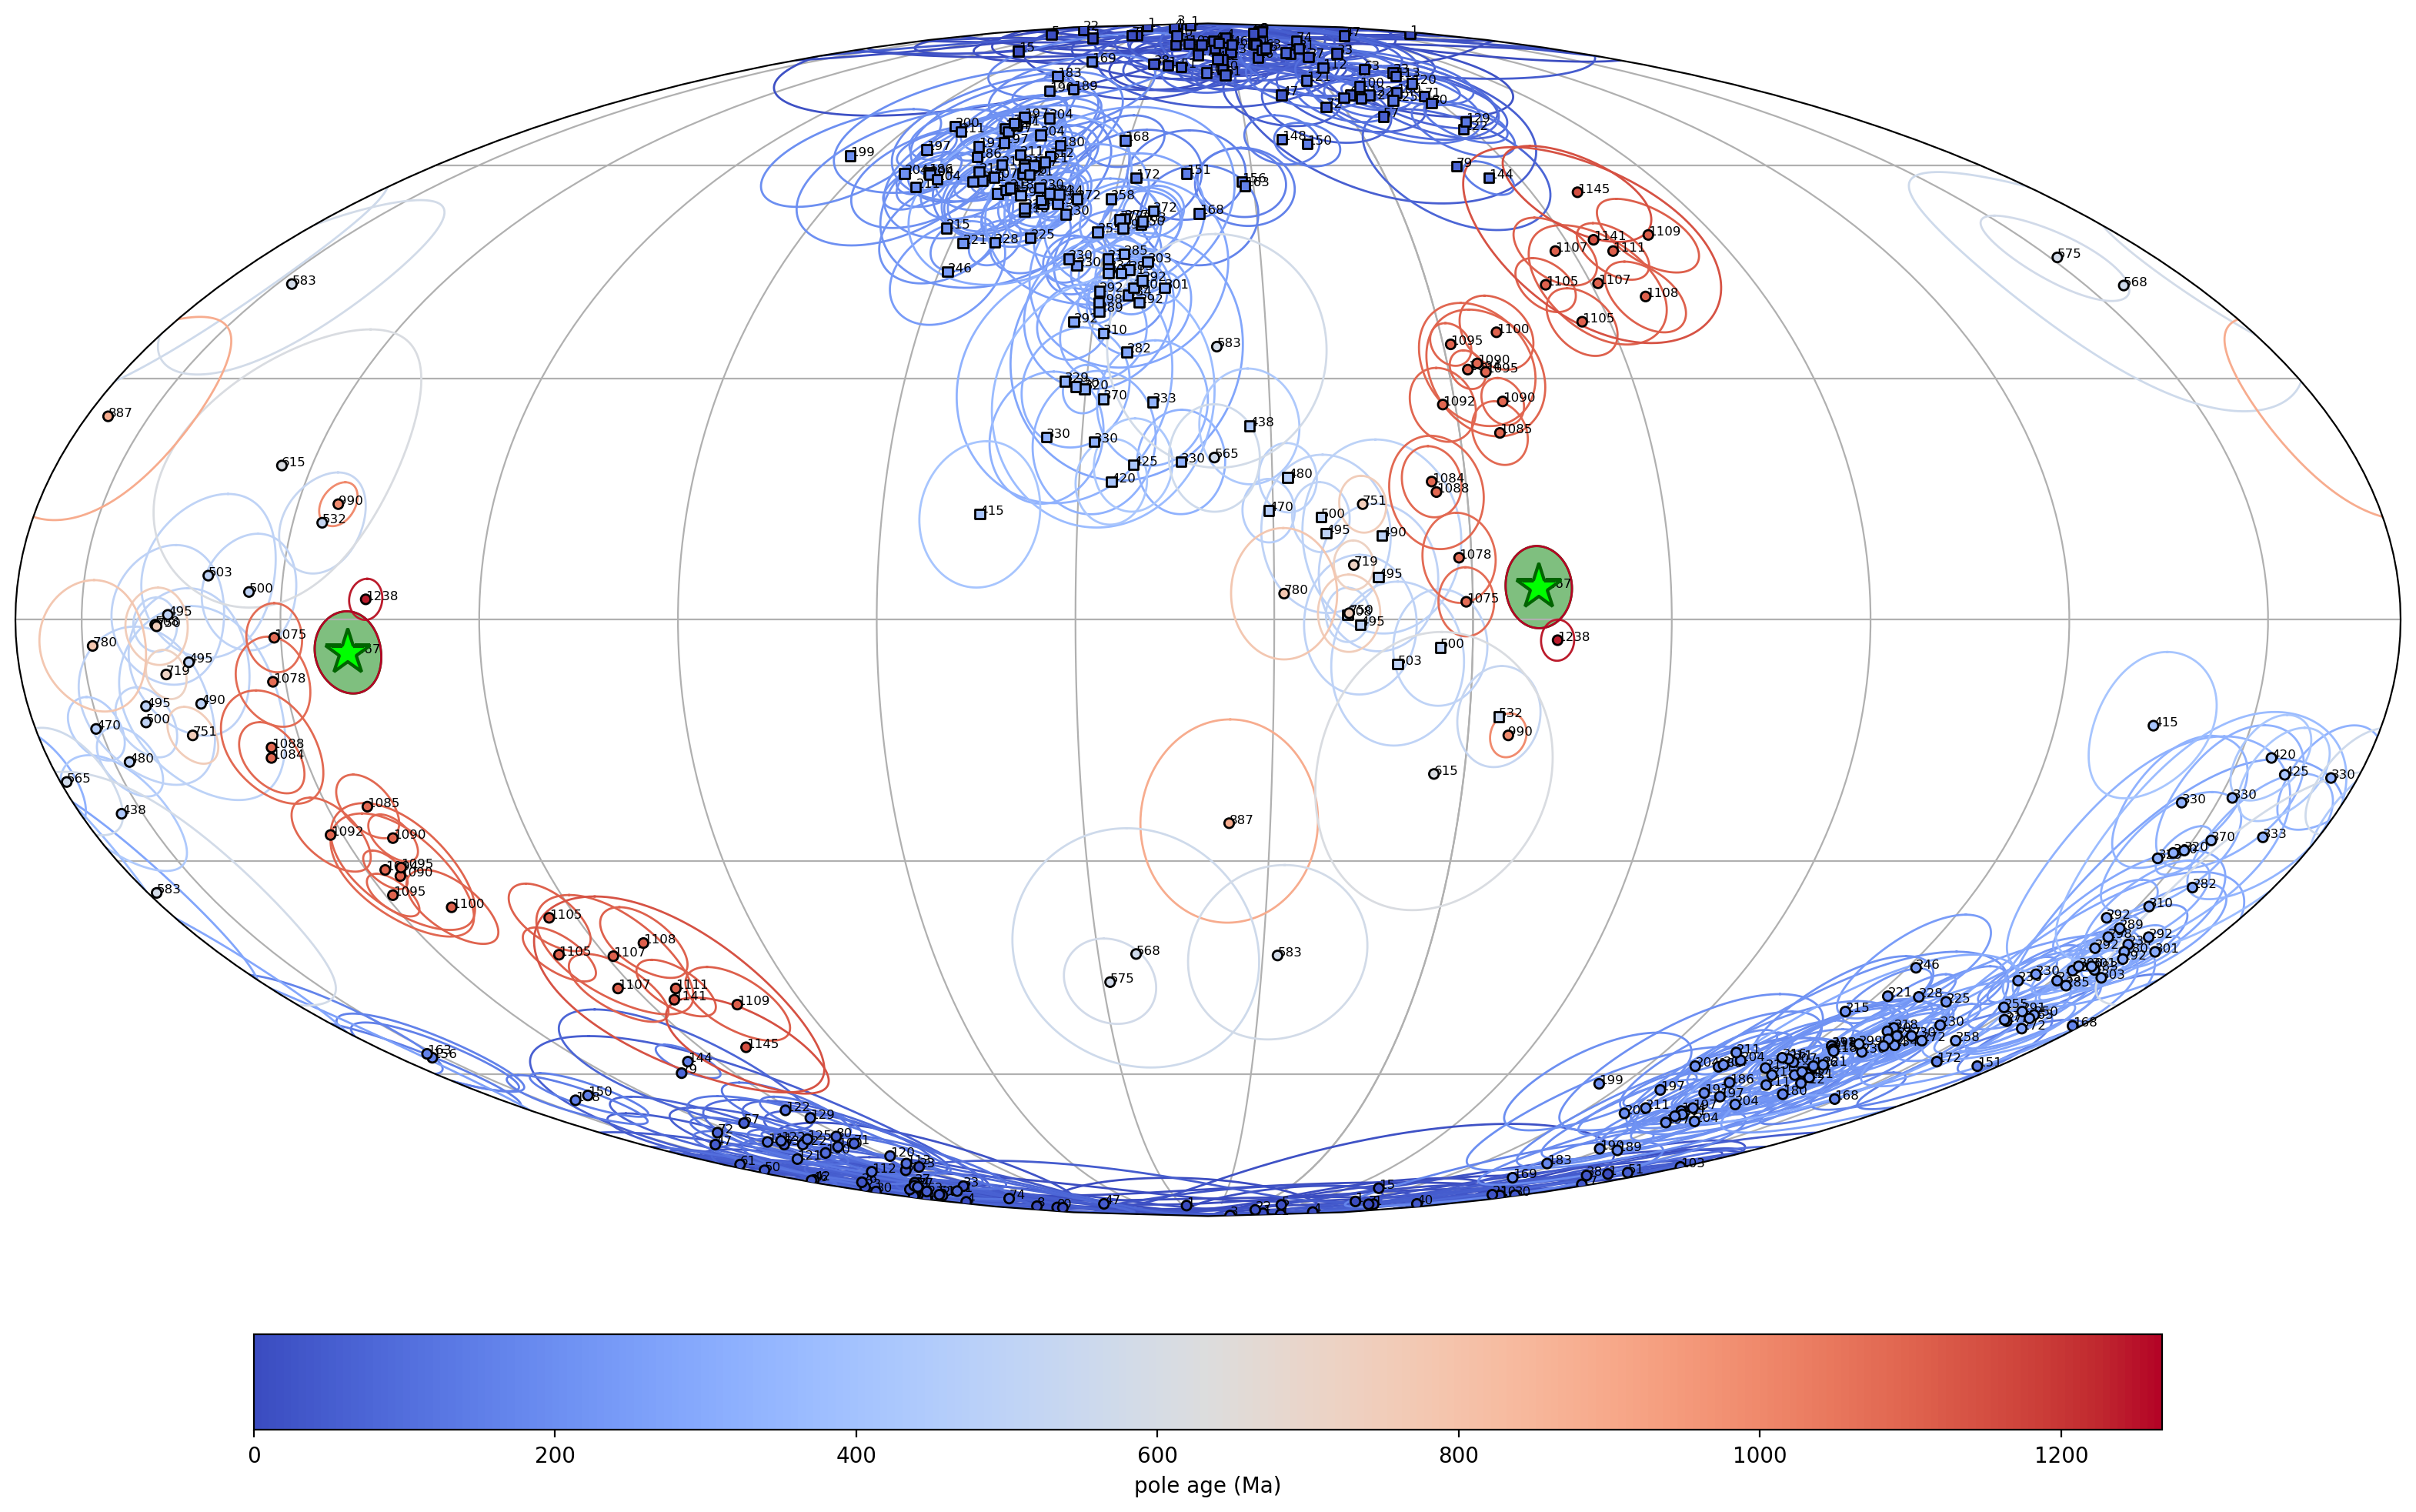

<GeoAxes: >

In [10]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Mackenzie dykes grand mean', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=mackenzie_pole['inc'], pole_plon=mackenzie_pole['dec'],
                     pole_A95=mackenzie_pole['alpha95'], pole_age=1267)

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | U-Pb baddeleyite 1267 ± 2 Ma on the Mackenzie swarm (LeCheminant & Heaman, 1989). |
| 2 | Techniques and statistical analysis | **1** | AF + thermal demagnetization; the Mackenzie grand mean (Buchan et al., 2000) averages multiple sub-areas. |
| 3 | Magnetic mineralogy characterized | **1** | Magnetite remanence characterized in the source studies. |
| 4 | Field tests constrain age of magnetization | **C** | Positive baked-contact test (baked country rock at the diabase contacts carries the diabase direction). |
| 5 | Structural control / tectonic coherence | **1** | Autochthonous Canadian Shield; vertical dykes / shallow sills. |
| 6 | Presence of reversals | **0** | Single polarity. |
| 7 | No resemblance to younger poles | **1** | A well-resolved Mesoproterozoic key pole, distinct from younger poles. |
| | Total | **6/7** | Grade A |

## Nordic workshop summary

The Mackenzie pole is reported as the prior-compilation grand mean of Buchan et
al. (2000) (4°N/190°E, A95 5°, N=5), the comprehensive Mackenzie dyke-swarm key
pole. The Irving et al. (1972) Mackenzie diabase sub-pole (0.7°N/182.7°E, N=10)
is recreated at the site level above, with its positive baked-contact test;
the missing location pole in the source contribution is restored.

The grand-mean pole is read directly from the previous compilation (Evans et al., 2021) for the export, since the site-level recreation here covers only the Irving et al. (1972) Mackenzie diabase (an incomplete subset of the grand mean's contributing sites). A fuller site-level compilation that brings in all of the Buchan et al. (2000) sub-area studies is planned, after which this pole can be rebuilt from the complete site list.

### Primary remanence pole

| | This study (site VGPs) | Buchan et al. (2000) | Previous Nordic compilation |
|---|---|---|---|
| Component | Primary ChRM (magnetite); single polarity (Mackenzie diabase) | Mackenzie dykes grand mean (normal) | Mackenzie dykes grand mean (from Buchan+00) |
| N (sites) | 10 | 14 | 5 |
| N (specimens) | 49 | — | — |
| Dec (°) | 249.3 | 268 | 243.9 |
| Inc (°) | 21.1 | 12 | 29.7 |
| k (direction) | 55.5 | — | 1000 |
| α95 (direction, °) | 6.5 | — | 0.1 |
| Pole lat (°N) | 0.7 | 4 | 4.0 |
| Pole lon (°E) | 182.7 | 190 | 190.0 |
| A95, pole (°) | 5.6 | 5 | 5.0 |
| dp / dm (°) | — | — | 5.0 / 5.0 |


In [11]:
# The site-level pole above is built from an incomplete subset of the sites that go into
# the prior-compilation grand mean. For the Nordic export we therefore adopt the published
# grand-mean pole from the previous compilation (Evans et al., 2021); a fuller site-level
# compilation that brings in the remaining studies is planned, after which this pole can be
# rebuilt from the complete site list.
evans = pd.read_csv('../data/Evans_et_al_2021_compilation.csv')
crow = evans[evans['ROCKNAME'] == 'Mackenzie dykes grand mean'].iloc[0]
pole_compilation = {'dec': float(crow['PLONG']), 'inc': float(crow['PLAT']),
                    'alpha95': float(crow['A95']), 'n': int(float(crow['B']))}
dir_compilation = {'dec': float(crow['DEC']), 'inc': float(crow['INC']),
                   'alpha95': float(crow['ED95']), 'k': float(crow['KD'])}
sites_compilation = pd.DataFrame([{'dir_tilt_correction': int(float(crow['TILT'])),
                                   'dir_n_samples': int(float(crow['N']))}])
print('adopted prior-compilation pole (Evans et al., 2021):')
print(f"  {pole_compilation['inc']:.1f} N / {pole_compilation['dec']:.1f} E, "
      f"A95 {pole_compilation['alpha95']:.1f}, B {pole_compilation['n']} sites, N {int(float(crow['N']))} samples")

adopted prior-compilation pole (Evans et al., 2021):
  4.0 N / 190.0 E, A95 5.0, B 5 sites, N 1000 samples


In [12]:
mackenzie_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Mackenzie dykes grand mean',
    sites=sites_compilation,
    dir_mean=dir_compilation,
    pole_mean=pole_compilation,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='Characteristic remanent magnetization (magnetite); single polarity (grand mean)',
    tests='C+ (positive baked-contact test; baked country rock carries the diabase direction)',
    gpmdb_number='B+00',
    percent_reversed=0,
    demag_code=3,
    R1=1, R2=1, R3=1, R4='C', R5=1, R6=0, R7=1, Grade='A',
    nominal_age=1267, lomagage=1265, himagage=1269,
    REF_method="- nominal age: 1267 Ma, lomagage 1265 Ma, himagage 1269 Ma.\n- LeCheminant and Heaman, 1989 dated 7 fractions of baddeleyite from four locations and got a concorida upper intercept age of 1267 ± 2 Ma. This age remains the most recent direct dating study for the Mackenzie dike swarm.",
    POLE_AUTHORS='Buchan, K. L., et al. (grand mean); Irving, E., Donaldson, J. A., & Park, J. K. (Mackenzie diabase)',
    YEAR=2000,
    JOURNAL='Canadian Journal of Earth Sciences',
    VOLUME='',
    VPAGES='',
    TITLE='Mackenzie dyke swarm grand mean (Buchan et al., 2000); Mackenzie diabase site data from Irving et al. (1972)',
    COMMENT='Mackenzie grand mean pole reported as the Buchan et al. (2000). Future plans to compile at site level.'
)
pt.save_nordic_summary(mackenzie_summary, '1267_Mackenzie')
mackenzie_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,Mackenzie dykes grand mean,GPMDB:B+00,Characteristic remanent magnetization (magneti...,C+ (positive baked-contact test; baked country...,0,62.5,249.0,5,1000,...,1269,"- nominal age: 1267 Ma, lomagage 1265 Ma, hima...",Mackenzie dykes grand mean,"Buchan, K. L., et al. (grand mean); Irving, E....",2000,Canadian Journal of Earth Sciences,,,Mackenzie dyke swarm grand mean (Buchan et al....,Mackenzie grand mean pole reported as the Buch...
